In [1]:
import pandas as pd
import glob
import os

csv_files = glob.glob('*.csv')

csv_files.sort()

df_list = [pd.read_csv(file) for file in csv_files]

main = pd.concat(df_list, ignore_index=True)

print(f"Total rows and columns: {main.shape}")
display(main.head())

Total rows and columns: (1981050, 60)


,REC_NUM,SURVYEAR,SURVMNTH,LFSSTAT,PROV,CMA,AGE_12,AGE_6,GENDER,MARSTAT,...,LKATADS,LKANSADS,LKOTHERN,PRIORACT,YNOLOOK,TLOLOOK,SCHOOLN,EFAMTYPE,AGYOWNK,FINALWT
0,1,2022,9,1,35,0,7,NaN,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4,4.0,413
1,2,2022,9,4,13,0,12,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN,72
2,3,2022,9,1,46,6,7,NaN,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3,2.0,107
3,4,2022,9,1,59,0,9,NaN,1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,14,NaN,815
4,5,2022,9,1,35,4,4,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3,1.0,245


In [2]:
# Convert implied decimals for hours variables
main['AHRSMAIN'] = main['AHRSMAIN'] / 10
main['UHRSMAIN'] = main['UHRSMAIN'] / 10
main['XTRAHRS'] = main['XTRAHRS'] / 10

In [3]:
# 1. Load the CPI data
cpi_df = pd.read_excel('CPI.xlsx')

# 2. Extract Year and Month from the 'date' column in CPI.xlsx to match 'main'
# This ensures the merge happens correctly for each specific time period
cpi_df['date'] = pd.to_datetime(cpi_df['date'])
cpi_df['SURVYEAR'] = cpi_df['date'].dt.year
cpi_df['SURVMNTH'] = cpi_df['date'].dt.month

# 3. Merge the CPI values into your main dataframe
# We only need the Year, Month, and the specific CPI column (V41690973 / Column B)
main = main.merge(cpi_df[['SURVYEAR', 'SURVMNTH', 'CPI']], 
                 on=['SURVYEAR', 'SURVMNTH'], 
                 how='left')

# 4. Deflate the wages to create "RealHRLYEARN"
# Formula: (Nominal Wage / CPI) * 100
# This adjusts the hourly earnings to a consistent price level (base year)
main['RealHRLYEARN'] = (main['HRLYEARN'] / main['CPI']) * 100

# Optional: Verify the first few rows of the new calculation
display(main[['SURVYEAR', 'SURVMNTH', 'HRLYEARN', 'CPI', 'RealHRLYEARN']].head())

,SURVYEAR,SURVMNTH,HRLYEARN,CPI,RealHRLYEARN
0,2022,9,3300.0,152.7,2161.100196
1,2022,9,NaN,152.7,NaN
2,2022,9,1350.0,152.7,884.086444
3,2022,9,NaN,152.7,NaN
4,2022,9,5800.0,152.7,3798.297315


In [7]:
main['RealHRLYEARN'] = main['RealHRLYEARN'] / 100
display(main['RealHRLYEARN'])

0          21.611002
1                NaN
2           8.840864
3                NaN
4          37.982973
             ...    
1981045     9.815951
1981046    11.349693
1981047    36.288344
1981048          NaN
1981049    10.582822
Name: RealHRLYEARN, Length: 1981050, dtype: float64

In [9]:
# Create a dictionary defining the mapping rules
status_mapping = {
    1: "Employed",
    2: "EmployedAbsent",
    3: "Unemployed",
    4: "NotInLaborForce"
}

# Apply the mapping to the 'Ifsstat' column to create the new column
main['EmploymentStatus'] = main['LFSSTAT'].map(status_mapping)

# Optional: Check the value counts to make sure the mapping worked correctly
print(main['EmploymentStatus'].value_counts(dropna=False))

EmploymentStatus
Employed           1070128
NotInLaborForce     749507
EmployedAbsent       93365
Unemployed           68050
Name: count, dtype: int64


In [11]:
# Create the new variable by squaring the 'TENURE' column
main['TENUREsq'] = main['TENURE'] ** 2

# Optional: Verify the calculation by checking the first few rows of both columns
display(main[['TENURE', 'TENUREsq']].head())

,TENURE,TENUREsq
0,22.0,484.0
1,NaN,NaN
2,143.0,20449.0
3,240.0,57600.0
4,6.0,36.0


In [13]:
# Create a dictionary mapping each 'educ' code to its corresponding category label
education_mapping = {
    0: "BelowHighSch",
    1: "BelowHighSch",
    2: "HighSch",
    3: "PostSec",
    4: "PostSec",
    5: "Bach",
    6: "AboveBach"
}

# Apply the mapping to create the new 'Education' column
main['Education'] = main['EDUC'].map(education_mapping)

# Optional: Check the value counts to ensure everything mapped correctly
print(main['Education'].value_counts(dropna=False))

Education
PostSec         768130
HighSch         386332
Bach            358422
BelowHighSch    286931
AboveBach       181235
Name: count, dtype: int64


In [15]:
# Create a dictionary for the specific mapping conditions
# We include both integers and strings just in case the CSV loaded them as text
pt_mapping = {
    1: 0, '1': 0,  # Full-time becomes 0
    2: 1, '2': 1   # Part-time becomes 1
}

# Apply the mapping to the 'FTPTMAIN' column
main['PartTime'] = main['FTPTMAIN'].map(pt_mapping)

# Optional: Verify the distribution, ensuring the blanks/unmapped values became NaN
print(main['PartTime'].value_counts(dropna=False))

PartTime
0.0    946307
NaN    817557
1.0    217186
Name: count, dtype: int64


In [17]:
# Create a dictionary mapping the marital status codes to the new dummy variable
# We include strings as well, just in case the data loaded as text
partner_mapping = {
    1: 1, '1': 1,
    2: 1, '2': 1,
    3: 0, '3': 0,
    4: 0, '4': 0,
    5: 0, '5': 0,
    6: 0, '6': 0
}

# Apply the mapping to the 'MARSTAT' column
main['HavePartner'] = main['MARSTAT'].map(partner_mapping)

# Optional: Verify the value counts to ensure the mapping worked correctly
print(main['HavePartner'].value_counts(dropna=False))

HavePartner
1    1191472
0     789578
Name: count, dtype: int64


In [19]:
# Create a dictionary mapping the gender codes to the new dummy variable
# (Including string versions just in case the data is stored as text)
gender_mapping = {
    1: 1, '1': 1,  # Male becomes 1
    2: 0, '2': 0   # Female becomes 0
}

# Apply the mapping to the 'GENDER' column
main['Male'] = main['GENDER'].map(gender_mapping)

# Optional: Verify the value counts to ensure the mapping worked correctly
print(main['Male'].value_counts(dropna=False))

Male
0    1016431
1     964619
Name: count, dtype: int64


In [21]:
# Create a dictionary mapping the multiple job status codes
# (Including string versions just in case the data loaded as text)
mjh_mapping = {
    2: 1, '2': 1,  # Has multiple jobs becomes 1
    1: 0, '1': 0   # Single job becomes 0
}

# Apply the mapping to the 'MJH' column
main['MultipleJob'] = main['MJH'].map(mjh_mapping)

# Optional: Verify the value counts to ensure the blanks were handled properly
print(main['MultipleJob'].value_counts(dropna=False))

MultipleJob
0.0    1098182
NaN     817557
1.0      65311
Name: count, dtype: int64


In [23]:
main['OTper'] = main['XTRAHRS'] / main['AHRSMAIN']

# FOR MODEL 1

In [26]:
tax_break_condition = (
    ((main['SURVYEAR'] == 2025) & (main['SURVMNTH'].isin([1, 2]))) | 
    ((main['SURVYEAR'] == 2024) & (main['SURVMNTH'] == 12))
)

# Create the new dummy variable (True becomes 1, False becomes 0)
main['TaxBreakTime'] = tax_break_condition.astype(int)

display(main.groupby(['SURVYEAR', 'SURVMNTH', 'TaxBreakTime']).size().reset_index(name='Count'))

,SURVYEAR,SURVMNTH,TaxBreakTime,Count
0,2022,9,0,110439
1,2022,10,0,110059
2,2022,11,0,109348
3,2022,12,0,110147
4,2023,1,0,108064
5,2023,2,0,104851
6,2023,9,0,108982
7,2023,10,0,108602
8,2023,11,0,108149
9,2023,12,0,108024


In [28]:
# Define the list of province codes that receive the high tax break
high_tax_provinces = [10, 11, 12, 13, 35]

# Create the dummy variable: 1 if PROV is in the list, 0 otherwise
main['HighTaxBreakProv'] = main['PROV'].isin(high_tax_provinces).astype(int)

# Optional: Verify the assignment by checking the cross-tabulation
# This shows how the 1s and 0s are distributed across the different provinces
display(pd.crosstab(main['PROV'], main['HighTaxBreakProv'], margins=True))

HighTaxBreakProv,0,1,All
PROV,,,
10,0,87560,87560
11,0,42939,42939
12,0,95110,95110
13,0,100226,100226
24,361309,0,361309
35,0,649250,649250
46,136339,0,136339
47,114136,0,114136
48,149080,0,149080


In [29]:
import numpy as np

# Create a mapping for the specific month groups
holiday_mapping = {
    12: 1, 1: 0, 2: 0,  # Winter/Holiday months
    9: 0, 10: 0, 11: 1  # Autumn months
}

# Apply the mapping to the 'SURVMNTH' column
# Months 3 through 8 will automatically become NaN
main['Holiday'] = main['SURVMNTH'].map(holiday_mapping)

# Optional: Verify the distribution to see how the months were categorized
print(main.groupby(['SURVMNTH', 'Holiday']).size().reset_index(name='Count'))

   SURVMNTH  Holiday   Count
0         1        0  329198
1         2        0  328563
2         9        0  331066
3        10        0  331380
4        11        1  330604
5        12        1  330239


In [32]:
import numpy as np
import pandas as pd

# 1. Convert NAICS_21 to numeric values safely. 
# errors='coerce' automatically turns text like 'blank' or empty strings into NaN.
# It also correctly parses padded strings like '01' as the integer 1.
naics_numeric = pd.to_numeric(main['NAICS_21'], errors='coerce')

# 2. Initialize the entire column with NaN (this securely handles all blanks)
main['FoodServiceSector'] = np.nan

# 3. Identify all valid industry rows (codes 1 through 21) and set them to 0
valid_industries = (naics_numeric >= 1) & (naics_numeric <= 21)
main.loc[valid_industries, 'FoodServiceSector'] = 0

# 4. Overwrite the specific food service sector (code 19) to 1
main.loc[naics_numeric == 19, 'FoodServiceSector'] = 1

# Optional: Verify the new distribution to ensure blanks stayed as NaN
print(main['FoodServiceSector'].value_counts(dropna=False))

FoodServiceSector
0.0    1220821
NaN     685027
1.0      75202
Name: count, dtype: int64


In [34]:
# Create the WeeklyIncome variable by multiplying hourly earnings and actual hours
main['WeeklyIncome'] = main['RealHRLYEARN'] * main['AHRSMAIN']

# Optional: Check for any missing values created by the multiplication
# (If either source variable is NaN, WeeklyIncome will also be NaN)
print(f"Number of rows with missing WeeklyIncome: {main['WeeklyIncome'].isna().sum()}")

# View the first few rows to verify the calculation
display(main[['RealHRLYEARN', 'AHRSMAIN', 'WeeklyIncome']].head())

Number of rows with missing WeeklyIncome: 976371


,RealHRLYEARN,AHRSMAIN,WeeklyIncome
0,21.611002,35.0,756.385069
1,NaN,NaN,NaN
2,8.840864,52.0,459.724951
3,NaN,70.0,NaN
4,37.982973,40.0,1519.318926


# For model 2

In [37]:
# Check for NAICS_21 == 19 (handling both integer and string formats) 
# AND LFSSTAT == 1
participation_condition = (main['NAICS_21'].isin([19, '19'])) & (main['LFSSTAT'] == 1)

# Create the new variable, converting True/False directly to 1/0
main['FoodServiceParticipationRate'] = participation_condition.astype(int)

# Optional: Verify the breakdown of the new variable
print(main['FoodServiceParticipationRate'].value_counts(dropna=False))

FoodServiceParticipationRate
0    1922938
1      58112
Name: count, dtype: int64


# Pre trend

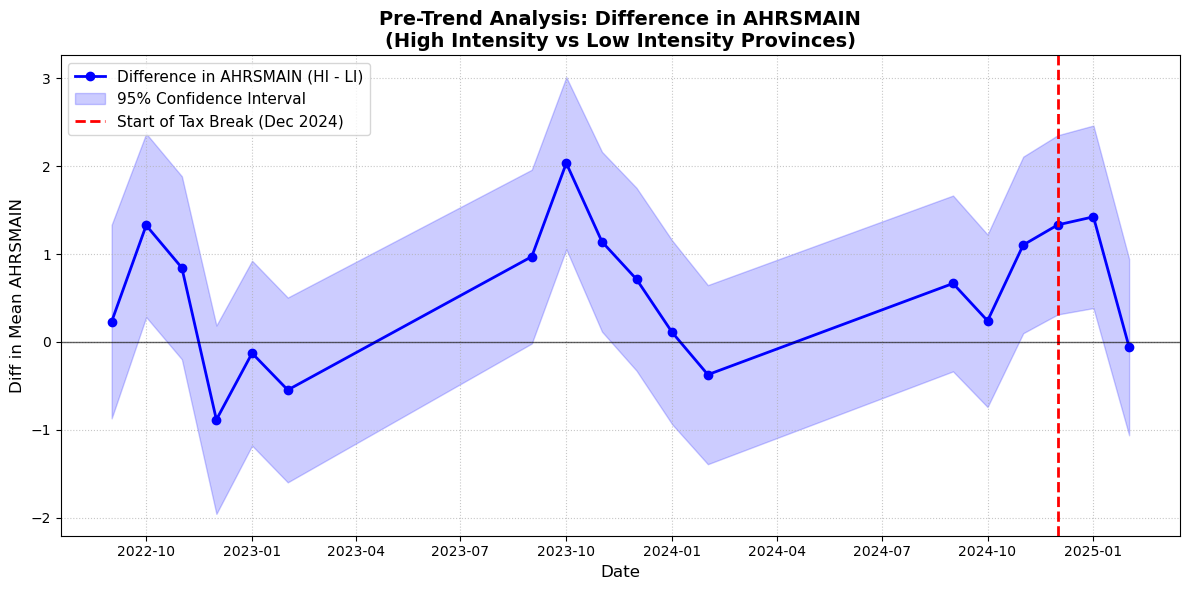

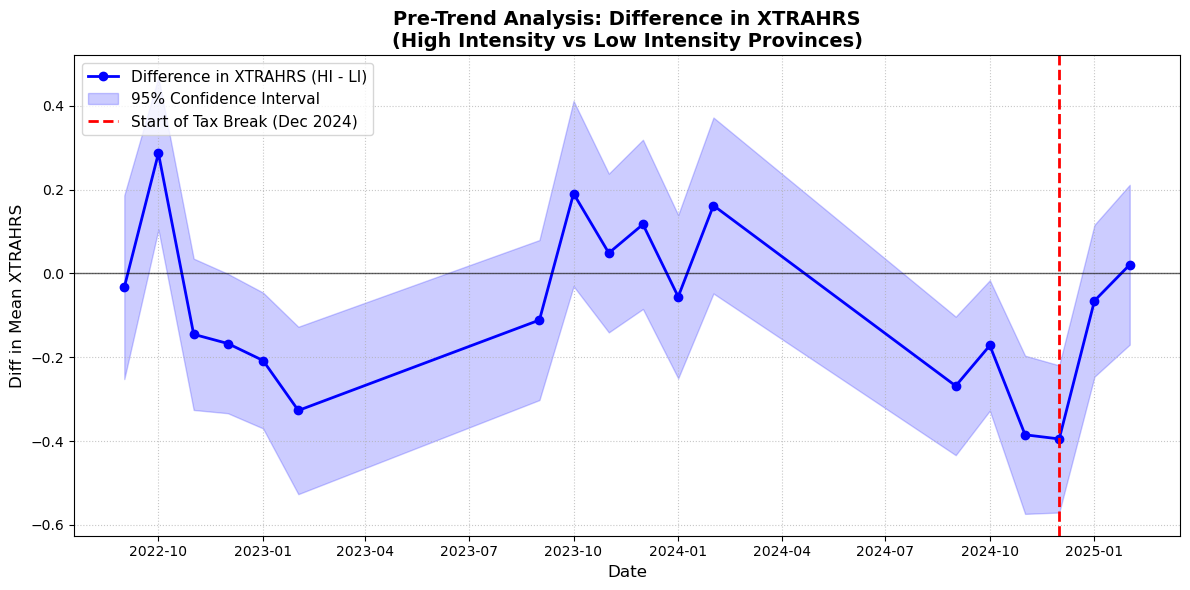

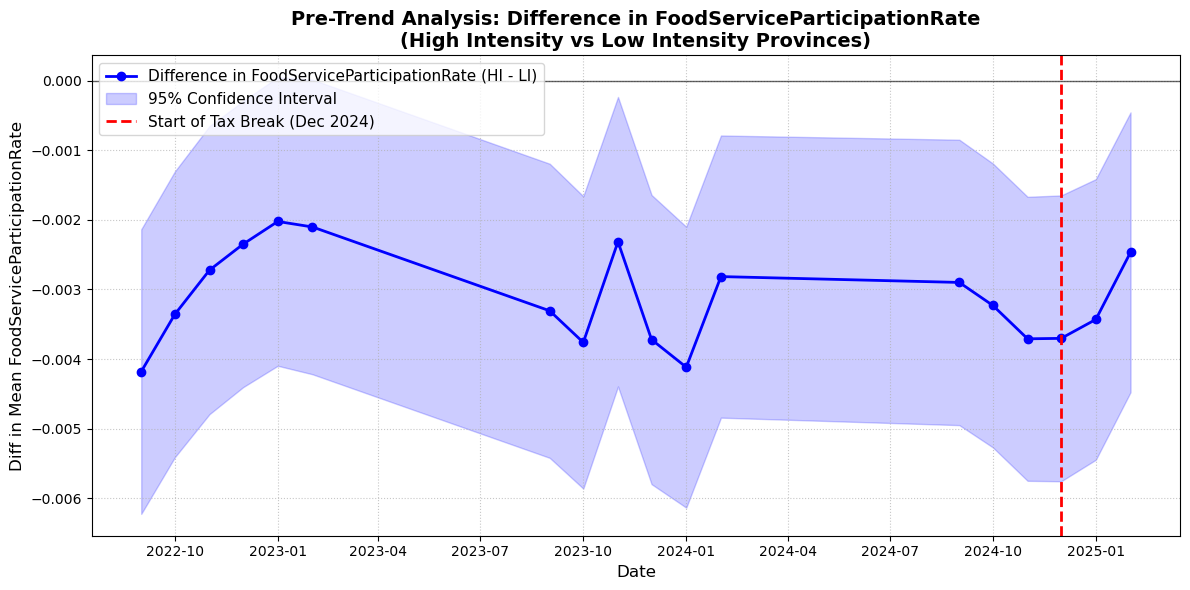

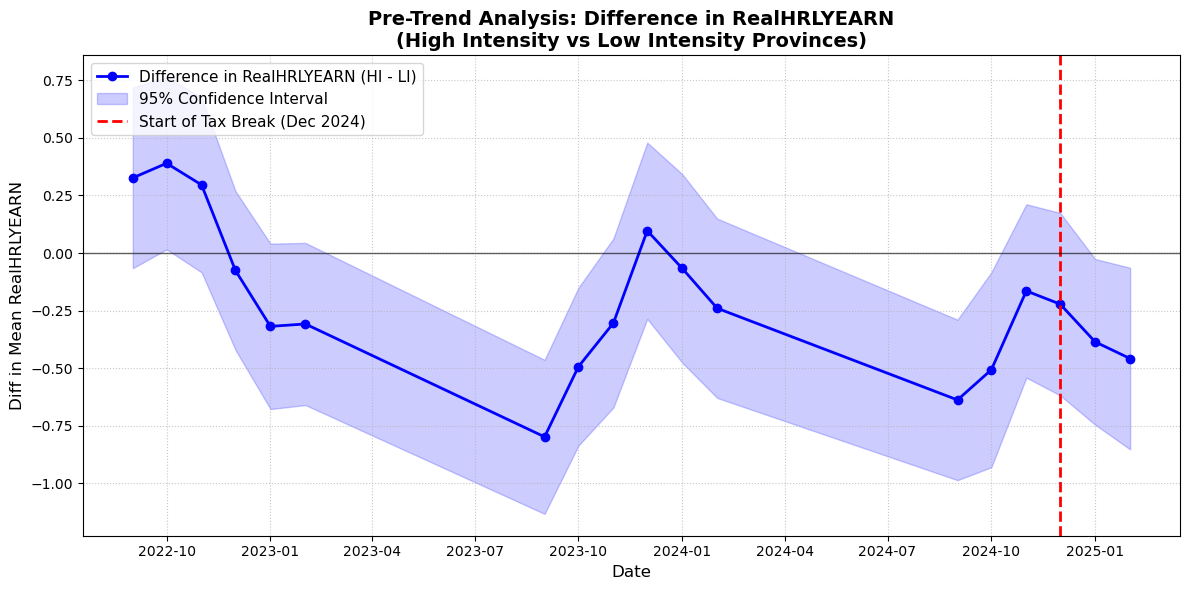

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import DescrStatsW

def plot_all_pretrends(df, target_vars, weight_col='FINALWT'):
    """
    Generates normalized, weighted pre-trend graphs for a list of variables.
    Automatically adjusts the sample filter based on the target variable.
    """
    # 1. Create a clean 'Date' column on a copy of the dataframe to avoid warnings
    work_df = df.copy()
    work_df['Date'] = pd.to_datetime(
        work_df['SURVYEAR'].astype(str) + '-' + 
        work_df['SURVMNTH'].astype(str).str.zfill(2) + '-01'
    )
    
    # Define timeframe
    start_date = pd.to_datetime('2022-09-01')
    end_date = pd.to_datetime('2025-02-01')
    work_df = work_df[(work_df['Date'] >= start_date) & (work_df['Date'] <= end_date)]

    # 2. Loop through each requested variable
    for y_var in target_vars:
        
        # --- Smart Filtering ---
        if y_var == 'FoodServiceParticipationRate':
            # For participation rate, we need the whole labor force (no sector filter)
            plot_df = work_df.copy()
        else:
            # For hours and wages, restrict to Employed/EmployedAbsent in the target sector
            plot_df = work_df[
                (work_df['EmploymentStatus'].isin(["Employed", "EmployedAbsent"])) & 
                (work_df['FoodServiceSector'] == 1)
            ].copy()

        # 3. Calculate Normalized Weighted Means and Standard Errors
        results = []
        for (date, is_high), group_df in plot_df.groupby(['Date', 'HighTaxBreakProv']):
            # Drop NaNs for the specific y_var and weight column
            clean_group = group_df.dropna(subset=[y_var, weight_col])
            n_obs = len(clean_group)
            
            if n_obs > 1:
                # NORMALIZATION: Scale weights to sum to actual sample size (N)
                raw_weights = clean_group[weight_col]
                norm_weights = raw_weights * (n_obs / raw_weights.sum())
                
                # Calculate stats
                wq = DescrStatsW(data=clean_group[y_var], weights=norm_weights)
                
                results.append({
                    'Date': date,
                    'HighTaxBreakProv': is_high,
                    'w_mean': wq.mean,             
                    'w_std_error': wq.std_mean 
                })

        stats_df = pd.DataFrame(results)

        # 4. Pivot and calculate differences
        pivot_mean = stats_df.pivot(index='Date', columns='HighTaxBreakProv', values='w_mean')
        pivot_se = stats_df.pivot(index='Date', columns='HighTaxBreakProv', values='w_std_error')

        difference = pivot_mean[1] - pivot_mean[0]
        se_diff = np.sqrt(pivot_se[1]**2 + pivot_se[0]**2)

        # 95% Confidence Interval
        ci_upper = difference + 1.96 * se_diff
        ci_lower = difference - 1.96 * se_diff

        # 5. Build the Graph
        plt.figure(figsize=(12, 6))
        plt.plot(difference.index, difference, marker='o', linestyle='-', color='blue', 
                 linewidth=2, label=f'Difference in {y_var} (HI - LI)')
        
        plt.fill_between(difference.index, ci_lower, ci_upper, color='blue', alpha=0.2, 
                         label='95% Confidence Interval')

        plt.axvline(x=pd.to_datetime('2024-12-01'), color='red', linestyle='--', 
                    linewidth=2, label='Start of Tax Break (Dec 2024)')
        plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.6)

        # Dynamic Formatting
        plt.title(f'Pre-Trend Analysis: Difference in {y_var}\n(High Intensity vs Low Intensity Provinces)', 
                  fontsize=14, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel(f'Diff in Mean {y_var}', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(fontsize=11, loc='upper left')
        plt.tight_layout()

        # Display the plot
        plt.show()

# Run the function on your dataframe
variables_to_test = ['AHRSMAIN', 'XTRAHRS', 'FoodServiceParticipationRate', 'RealHRLYEARN']
plot_all_pretrends(main, variables_to_test)

# RUN MODEL 1

In [63]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. DATA FILTERING
# Filter for Employed individuals in the Food Service Sector
target_df = main[(main['EmploymentStatus'] == "Employed") & (main['FoodServiceSector'] == 1)].copy()

# 2. WEIGHT NORMALIZATION
# Normalize FINALWT so that the mean of the weight is 1.0. 
# This preserves the population representation while keeping p-values realistic.
target_df['norm_weight'] = target_df['FINALWT'] / target_df['FINALWT'].mean()

# 3. DEFINE THE MODEL FORMULA
# Triple interaction: HighTaxBreakProv * Holiday * TaxBreakTime
formula = (
    "AHRSMAIN ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
    "C(Education, Treatment(reference='BelowHighSch')) + "
    "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
)

# 4. INITIALIZE THE MODEL (WLS)
# Using 'missing=drop' removes any rows where variables in the formula are NaN
ddd_model = smf.wls(formula=formula, data=target_df, weights=target_df['norm_weight'], missing='drop')

# 5. ALIGN CLUSTERS AND FIT
# We extract row_labels from the model to ensure our 'SURVYEAR' vector 
# is the exact same length as the data actually used in the regression.
used_indices = ddd_model.data.row_labels
year_clusters = target_df.loc[used_indices, 'SURVYEAR']

# Fit with Clustered Robust Standard Errors (handles heteroskedasticity and year-correlation)
ddd_results = ddd_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': year_clusters}
)

# 6. RESULTS
print(ddd_results.summary())

                            WLS Regression Results                            
Dep. Variable:               AHRSMAIN   R-squared:                       0.664
Model:                            WLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     1355.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           3.40e-05
Time:                        20:20:37   Log-Likelihood:            -1.9523e+05
No. Observations:               53796   AIC:                         3.905e+05
Df Residuals:                   53777   BIC:                         3.907e+05
Df Model:                          18                                         
Covariance Type:              cluster                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

D:\Anaconda\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [45]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. DATA FILTERING
# Filter for Employed individuals in the Food Service Sector
target_df = main[(main['EmploymentStatus'] == "Employed") & (main['FoodServiceSector'] == 1)].copy()

# 2. WEIGHT NORMALIZATION
# Normalize FINALWT so that the mean of the weight is 1.0. 
# This preserves the population representation while keeping p-values realistic.
target_df['norm_weight'] = target_df['FINALWT'] / target_df['FINALWT'].mean()

# 3. DEFINE THE MODEL FORMULA
# Triple interaction: HighTaxBreakProv * Holiday * TaxBreakTime
formula = (
    "XTRAHRS ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
    "C(Education, Treatment(reference='BelowHighSch')) + "
    "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
)

# 4. INITIALIZE THE MODEL (WLS)
# Using 'missing=drop' removes any rows where variables in the formula are NaN
ddd_model = smf.wls(formula=formula, data=target_df, weights=target_df['norm_weight'], missing='drop')

# 5. ALIGN CLUSTERS AND FIT
# We extract row_labels from the model to ensure our 'SURVYEAR' vector 
# is the exact same length as the data actually used in the regression.
used_indices = ddd_model.data.row_labels
year_clusters = target_df.loc[used_indices, 'SURVYEAR']

# Fit with Clustered Robust Standard Errors (handles heteroskedasticity and year-correlation)
ddd_results = ddd_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': year_clusters}
)

# 6. RESULTS
print(ddd_results.summary())

                            WLS Regression Results                            
Dep. Variable:                XTRAHRS   R-squared:                       0.033
Model:                            WLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     2.686
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.219
Time:                        14:20:44   Log-Likelihood:            -1.3615e+05
No. Observations:               53796   AIC:                         2.723e+05
Df Residuals:                   53777   BIC:                         2.725e+05
Df Model:                          18                                         
Covariance Type:              cluster                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

D:\Anaconda\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 3
  warnings.warn('covariance of constraints does not have full '


# RUN MODEL 2

In [51]:
import statsmodels.formula.api as smf

# 1. Define the DDD Linear Probability Model formula
# Y = FoodServiceParticipationRate
# Interactions: HighTaxBreak * Holiday * TaxBreakTime
# Controls: Education (base: BelowHighSch), Male, HavePartner
formula_ddd_lpm = (
    "FoodServiceParticipationRate ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
    "C(Education, Treatment(reference='BelowHighSch')) + Male + HavePartner"
)

# 2. Fit the OLS model on the full dataset ('main')
# missing='drop' will exclude rows where Holiday is NaN (months 3-8)
ddd_lpm_model = smf.ols(formula=formula_ddd_lpm, data=main, missing='drop')
ddd_lpm_results = ddd_lpm_model.fit(cov_type='HC1')  # Robust standard errors for LPM

# 3. Display results
print(ddd_lpm_results.summary())

                                 OLS Regression Results                                 
Dep. Variable:     FoodServiceParticipationRate   R-squared:                       0.008
Model:                                      OLS   Adj. R-squared:                  0.008
Method:                           Least Squares   F-statistic:                     1086.
Date:                          Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                                  20:06:52   Log-Likelihood:             7.2198e+05
No. Observations:                       1981050   AIC:                        -1.444e+06
Df Residuals:                           1981036   BIC:                        -1.444e+06
Df Model:                                    13                                         
Covariance Type:                            HC1                                         
                                                                     coef    std err          z      P>|z|    

# RUN MODEL 3

In [53]:
import statsmodels.formula.api as smf

# 1. Filter the dataset: Conditional on being "Employed" AND in the "FoodServiceSector"
# This remains the industry-specific focus for your causal analysis.
target_df = main[(main['EmploymentStatus'] == "Employed") & (main['FoodServiceSector'] == 1)].copy()

# 2. Define the regression formula
# Y variable is now HRLYEARN (Hourly Earnings)
# AHRSMAIN (Actual Hours) moves to the right-hand side as a control variable.
formula = (
    "WeeklyIncome ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
    "C(Education, Treatment(reference='BelowHighSch')) + "
    "AHRSMAIN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
)

# 3. Fit the Ordinary Least Squares (OLS) model
# We continue using cov_type='HC1' for robust standard errors.
ddd_wage_model = smf.ols(formula=formula, data=target_df, missing='drop')
ddd_wage_results = ddd_wage_model.fit(cov_type='HC1')

# 4. Print the regression table
print(ddd_wage_results.summary())

                            OLS Regression Results                            
Dep. Variable:           WeeklyIncome   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     3356.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:07:06   Log-Likelihood:            -3.5784e+05
No. Observations:               53796   AIC:                         7.157e+05
Df Residuals:                   53777   BIC:                         7.159e+05
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [45]:
import statsmodels.formula.api as smf

# 1. Filter the dataset: Conditional on being "Employed" AND in the "FoodServiceSector"
# This remains the industry-specific focus for your causal analysis.
target_df = main[(main['EmploymentStatus'] == "Employed") & (main['FoodServiceSector'] == 1)].copy()

# 2. Define the regression formula
# Y variable is now HRLYEARN (Hourly Earnings)
# AHRSMAIN (Actual Hours) moves to the right-hand side as a control variable.
formula = (
    "RealHRLYEARN ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
    "C(Education, Treatment(reference='BelowHighSch')) + "
    "AHRSMAIN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
)

# 3. Fit the Ordinary Least Squares (OLS) model
# We continue using cov_type='HC1' for robust standard errors.
ddd_wage_model = smf.ols(formula=formula, data=target_df, missing='drop')
ddd_wage_results = ddd_wage_model.fit(cov_type='HC1')

# 4. Print the regression table
print(ddd_wage_results.summary())

                            OLS Regression Results                            
Dep. Variable:           RealHRLYEARN   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     336.7
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:56   Log-Likelihood:            -1.5944e+05
No. Observations:               53796   AIC:                         3.189e+05
Df Residuals:                   53777   BIC:                         3.191e+05
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

# Placebo Tests

## Reg Total Hour by Sector

In [55]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def find_significant_sectors(df, alpha=0.05):
    # 1. Define the NAICS 21 dictionary from your codebook
    naics_mapping = {
        1: 'Agriculture',
        2: 'Forestry and logging and support activities for forestry',
        3: 'Fishing, hunting and trapping',
        4: 'Mining, quarrying, and oil and gas extraction',
        5: 'Utilities',
        6: 'Construction',
        7: 'Manufacturing - durable goods',
        8: 'Manufacturing - non-durable goods',
        9: 'Wholesale trade',
        10: 'Retail trade',
        11: 'Transportation and warehousing',
        12: 'Finance and insurance',
        13: 'Real estate and rental and leasing',
        14: 'Professional, scientific and technical services',
        15: 'Business, building and other support services',
        16: 'Educational services',
        17: 'Health care and social assistance',
        18: 'Information, culture and recreation',
        19: 'Accommodation and food services',
        20: 'Other services (except public administration)',
        21: 'Public administration'
    }

    # 2. Define the regression formula
    formula = (
        "AHRSMAIN ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
        "C(Education, Treatment(reference='BelowHighSch')) + "
        "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
    )

    # Convert NAICS_21 to numeric to ensure clean matching (handles '01' strings and 'blank')
    df['NAICS_numeric'] = pd.to_numeric(df['NAICS_21'], errors='coerce')
    
    # Base filter for employment status
    base_df = df[df['EmploymentStatus'] == "Employed"].copy()

    significant_results = []

    # 3. Loop through each sector
    for code, sector_name in naics_mapping.items():
        # Filter for the specific sector
        sector_df = base_df[base_df['NAICS_numeric'] == code]
        
        # Skip if there's very little data for this sector
        if len(sector_df) < 50:
            print(f"Skipping Sector {code} ({sector_name}): Not enough observations.")
            continue
            
        try:
            # Fit the model
            model = smf.ols(formula=formula, data=sector_df, missing='drop')
            results = model.fit(cov_type='HC1')
            
            # Extract p-values (using .get() defaults to 1.0 if the term was dropped due to collinearity)
            p_holiday_tax = results.pvalues.get('Holiday:TaxBreakTime', 1.0)
            p_ddd = results.pvalues.get('HighTaxBreakProv:Holiday:TaxBreakTime', 1.0)
            
            # Check for significance
            is_holiday_tax_sig = p_holiday_tax < alpha
            is_ddd_sig = p_ddd < alpha
            
            if is_holiday_tax_sig or is_ddd_sig:
                significant_results.append({
                    'NAICS_Code': code,
                    'Sector': sector_name,
                    'DiD_P-Value (Holiday:TaxBreakTime)': round(p_holiday_tax, 4),
                    'DiD_Coeff': round(results.params.get('Holiday:TaxBreakTime', 0), 4),
                    'DDD_P-Value (HighTaxBreakProv:Holiday:TaxBreakTime)': round(p_ddd, 4),
                    'DDD_Coeff': round(results.params.get('HighTaxBreakProv:Holiday:TaxBreakTime', 0), 4)
                })
                print(f"⭐ Significant Result Found in Sector {code}: {sector_name}")
                
        except Exception as e:
            print(f"Error running regression for Sector {code} ({sector_name}): {e}")

    # 4. Return results as a nicely formatted DataFrame
    if significant_results:
        return pd.DataFrame(significant_results)
    else:
        print("No sectors showed statistically significant results at the specified alpha level.")
        return pd.DataFrame()

# Run the function on your 'main' dataframe
# Setting alpha=0.05 for a 5% significance level
significant_sectors_df = find_significant_sectors(main, alpha=0.05)
display(significant_sectors_df)

⭐ Significant Result Found in Sector 6: Construction
⭐ Significant Result Found in Sector 7: Manufacturing - durable goods
⭐ Significant Result Found in Sector 10: Retail trade
⭐ Significant Result Found in Sector 12: Finance and insurance
⭐ Significant Result Found in Sector 14: Professional, scientific and technical services
⭐ Significant Result Found in Sector 16: Educational services
⭐ Significant Result Found in Sector 17: Health care and social assistance
⭐ Significant Result Found in Sector 19: Accommodation and food services
⭐ Significant Result Found in Sector 20: Other services (except public administration)
⭐ Significant Result Found in Sector 21: Public administration


,NAICS_Code,Sector,DiD_P-Value (Holiday:TaxBreakTime),DiD_Coeff,DDD_P-Value (HighTaxBreakProv:Holiday:TaxBreakTime),DDD_Coeff
0,6,Construction,0.0000,1.4811,0.1289,-0.6912
1,7,Manufacturing - durable goods,0.0000,1.1670,0.0001,-1.5820
2,10,Retail trade,0.0078,0.4497,0.4691,0.1765
3,12,Finance and insurance,0.0938,0.4703,0.0021,-1.1776
4,14,"Professional, scientific and technical services",0.0866,0.4339,0.0000,-1.6391
5,16,Educational services,0.0029,0.6928,0.1329,-0.5071
6,17,Health care and social assistance,0.0992,0.3012,0.0287,-0.5917
7,19,Accommodation and food services,0.0099,0.6505,0.7759,-0.1071
8,20,Other services (except public administration),0.0058,0.9649,0.0027,-1.6199
9,21,Public administration,0.0028,0.7201,0.0895,-0.5814


## Reg Total Hour by Sector with Clustering and Weight

In [71]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def find_significant_sectors(df, alpha=0.05):
    naics_mapping = {
        1: 'Agriculture',
        2: 'Forestry and logging',
        3: 'Fishing, hunting and trapping',
        4: 'Mining, quarrying, and oil/gas',
        5: 'Utilities',
        6: 'Construction',
        7: 'Manufacturing - durable',
        8: 'Manufacturing - non-durable',
        9: 'Wholesale trade',
        10: 'Retail trade',
        11: 'Transportation and warehousing',
        12: 'Finance and insurance',
        13: 'Real estate and rental/leasing',
        14: 'Professional, scientific and tech',
        15: 'Business, building and support',
        16: 'Educational services',
        17: 'Health care and social assistance',
        18: 'Information, culture and recreation',
        19: 'Accommodation and food services',
        20: 'Other services',
        21: 'Public administration'
    }

    formula = (
        "AHRSMAIN ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
        "C(Education, Treatment(reference='BelowHighSch')) + "
        "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
    )

    df['NAICS_numeric'] = pd.to_numeric(df['NAICS_21'], errors='coerce')
    base_df = df[df['EmploymentStatus'] == "Employed"].copy()

    significant_results = []

    for code, sector_name in naics_mapping.items():
        # 1. Sector-specific filtering
        sector_df = base_df[base_df['NAICS_numeric'] == code].copy()
        
        # 2. Skip if data is too thin or doesn't span multiple years (needed for clustering)
        if len(sector_df) < 100 or sector_df['SURVYEAR'].nunique() < 2:
            print(f"Skipping Sector {code} ({sector_name}): Insufficient data/years.")
            continue
            
        try:
            # 3. NORMALIZE WEIGHTS (Sector-specific)
            # We normalize within the sector so that the sum of weights = N of this sector
            sector_df['norm_weight'] = sector_df['FINALWT'] / sector_df['FINALWT'].mean()

            # 4. INITIALIZE WLS MODEL
            model = smf.wls(formula=formula, data=sector_df, weights=sector_df['norm_weight'], missing='drop')
            
            # 5. ALIGN CLUSTERS (Same logic as before to handle dropped NaNs)
            used_indices = model.data.row_labels
            year_clusters = sector_df.loc[used_indices, 'SURVYEAR']
            
            # 6. FIT WITH CLUSTERED ROBUST SEs
            # Cluster by year inherently provides heteroskedasticity-robustness
            results = model.fit(cov_type='cluster', cov_kwds={'groups': year_clusters})
            
            # 7. EXTRACT P-VALUES AND COEFFICIENTS
            # We look specifically for the DDD term
            ddd_term = 'HighTaxBreakProv:Holiday:TaxBreakTime'
            p_ddd = results.pvalues.get(ddd_term, 1.0)
            coeff_ddd = results.params.get(ddd_term, 0.0)
            
            # Also tracking the DiD interaction for the control group
            did_term = 'Holiday:TaxBreakTime'
            p_did = results.pvalues.get(did_term, 1.0)
            coeff_did = results.params.get(did_term, 0.0)

            # Check significance
            if p_ddd < alpha or p_did < alpha:
                significant_results.append({
                    'NAICS_Code': code,
                    'Sector': sector_name,
                    'DDD_Coeff': round(coeff_ddd, 4),
                    'DDD_P-Value': round(p_ddd, 4),
                    'DiD_Coeff': round(coeff_did, 4),
                    'DiD_P-Value': round(p_did, 4),
                    'N_Obs': len(used_indices)
                })
                print(f"⭐ Significant Result in {sector_name} (p={p_ddd:.4f})")
                
        except Exception as e:
            print(f"Error in Sector {code} ({sector_name}): {e}")

    if significant_results:
        return pd.DataFrame(significant_results).sort_values('DDD_P-Value')
    else:
        print("No sectors reached significance.")
        return pd.DataFrame()

# Execute
significant_sectors_df = find_significant_sectors(main, alpha=0.05)
display(significant_sectors_df)

⭐ Significant Result in Forestry and logging (p=0.0273)
⭐ Significant Result in Mining, quarrying, and oil/gas (p=0.0027)
⭐ Significant Result in Construction (p=0.0000)
⭐ Significant Result in Manufacturing - durable (p=0.0000)
⭐ Significant Result in Manufacturing - non-durable (p=0.0001)
⭐ Significant Result in Wholesale trade (p=0.0011)
⭐ Significant Result in Retail trade (p=0.0359)
⭐ Significant Result in Transportation and warehousing (p=0.0023)
⭐ Significant Result in Finance and insurance (p=0.0446)
⭐ Significant Result in Professional, scientific and tech (p=0.0000)
⭐ Significant Result in Health care and social assistance (p=0.0000)
⭐ Significant Result in Accommodation and food services (p=0.7783)
⭐ Significant Result in Other services (p=0.0000)


,NAICS_Code,Sector,DDD_Coeff,DDD_P-Value,DiD_Coeff,DiD_P-Value,N_Obs
2,6,Construction,-1.4380,0.0000,1.7591,0.0000,63645
3,7,Manufacturing - durable,-1.9826,0.0000,1.4885,0.0000,46816
9,14,"Professional, scientific and tech",-1.9057,0.0000,0.6568,0.1032,62791
10,17,Health care and social assistance,-0.8769,0.0000,0.2851,0.1727,135705
12,20,Other services,-2.6259,0.0000,1.3994,0.0006,30642
4,8,Manufacturing - non-durable,-0.9711,0.0001,0.4080,0.0013,40700
5,9,Wholesale trade,-0.3087,0.0011,0.2620,0.1601,31324
7,11,Transportation and warehousing,0.5345,0.0023,-0.4544,0.3069,45437
1,4,"Mining, quarrying, and oil/gas",-1.6324,0.0027,1.1545,0.0000,17878
0,2,Forestry and logging,-4.1856,0.0273,0.9070,0.0142,2439


## Reg OT by Sector

In [57]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def find_significant_sectors(df, alpha=0.05):
    # 1. Define the NAICS 21 dictionary from your codebook
    naics_mapping = {
        1: 'Agriculture',
        2: 'Forestry and logging and support activities for forestry',
        3: 'Fishing, hunting and trapping',
        4: 'Mining, quarrying, and oil and gas extraction',
        5: 'Utilities',
        6: 'Construction',
        7: 'Manufacturing - durable goods',
        8: 'Manufacturing - non-durable goods',
        9: 'Wholesale trade',
        10: 'Retail trade',
        11: 'Transportation and warehousing',
        12: 'Finance and insurance',
        13: 'Real estate and rental and leasing',
        14: 'Professional, scientific and technical services',
        15: 'Business, building and other support services',
        16: 'Educational services',
        17: 'Health care and social assistance',
        18: 'Information, culture and recreation',
        19: 'Accommodation and food services',
        20: 'Other services (except public administration)',
        21: 'Public administration'
    }

    # 2. Define the regression formula
    formula = (
        "XTRAHRS ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
        "C(Education, Treatment(reference='BelowHighSch')) + "
        "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
    )

    # Convert NAICS_21 to numeric to ensure clean matching (handles '01' strings and 'blank')
    df['NAICS_numeric'] = pd.to_numeric(df['NAICS_21'], errors='coerce')
    
    # Base filter for employment status
    base_df = df[df['EmploymentStatus'] == "Employed"].copy()

    significant_results = []

    # 3. Loop through each sector
    for code, sector_name in naics_mapping.items():
        # Filter for the specific sector
        sector_df = base_df[base_df['NAICS_numeric'] == code]
        
        # Skip if there's very little data for this sector
        if len(sector_df) < 50:
            print(f"Skipping Sector {code} ({sector_name}): Not enough observations.")
            continue
            
        try:
            # Fit the model
            model = smf.ols(formula=formula, data=sector_df, missing='drop')
            results = model.fit(cov_type='HC1')
            
            # Extract p-values (using .get() defaults to 1.0 if the term was dropped due to collinearity)
            p_holiday_tax = results.pvalues.get('Holiday:TaxBreakTime', 1.0)
            p_ddd = results.pvalues.get('HighTaxBreakProv:Holiday:TaxBreakTime', 1.0)
            
            # Check for significance
            is_holiday_tax_sig = p_holiday_tax < alpha
            is_ddd_sig = p_ddd < alpha
            
            if is_holiday_tax_sig or is_ddd_sig:
                significant_results.append({
                    'NAICS_Code': code,
                    'Sector': sector_name,
                    'DiD_P-Value (Holiday:TaxBreakTime)': round(p_holiday_tax, 4),
                    'DiD_Coeff': round(results.params.get('Holiday:TaxBreakTime', 0), 4),
                    'DDD_P-Value (HighTaxBreakProv:Holiday:TaxBreakTime)': round(p_ddd, 4),
                    'DDD_Coeff': round(results.params.get('HighTaxBreakProv:Holiday:TaxBreakTime', 0), 4)
                })
                print(f"⭐ Significant Result Found in Sector {code}: {sector_name}")
                
        except Exception as e:
            print(f"Error running regression for Sector {code} ({sector_name}): {e}")

    # 4. Return results as a nicely formatted DataFrame
    if significant_results:
        return pd.DataFrame(significant_results)
    else:
        print("No sectors showed statistically significant results at the specified alpha level.")
        return pd.DataFrame()

# Run the function on your 'main' dataframe
# Setting alpha=0.05 for a 5% significance level
significant_sectors_df = find_significant_sectors(main, alpha=0.05)
display(significant_sectors_df)

⭐ Significant Result Found in Sector 1: Agriculture
⭐ Significant Result Found in Sector 3: Fishing, hunting and trapping
⭐ Significant Result Found in Sector 6: Construction
⭐ Significant Result Found in Sector 10: Retail trade


,NAICS_Code,Sector,DiD_P-Value (Holiday:TaxBreakTime),DiD_Coeff,DDD_P-Value (HighTaxBreakProv:Holiday:TaxBreakTime),DDD_Coeff
0,1,Agriculture,0.0001,1.2029,0.2164,-0.5511
1,3,"Fishing, hunting and trapping",0.0178,2.1946,0.3030,-1.4719
2,6,Construction,0.0044,0.5030,0.8635,0.0423
3,10,Retail trade,0.3876,0.0522,0.0230,0.2100


## Reg OT by Sector with Clustering and Weight

In [77]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def find_significant_sectors(df, alpha=0.05):
    naics_mapping = {
        1: 'Agriculture',
        2: 'Forestry and logging',
        3: 'Fishing, hunting and trapping',
        4: 'Mining, quarrying, and oil/gas',
        5: 'Utilities',
        6: 'Construction',
        7: 'Manufacturing - durable',
        8: 'Manufacturing - non-durable',
        9: 'Wholesale trade',
        10: 'Retail trade',
        11: 'Transportation and warehousing',
        12: 'Finance and insurance',
        13: 'Real estate and rental/leasing',
        14: 'Professional, scientific and tech',
        15: 'Business, building and support',
        16: 'Educational services',
        17: 'Health care and social assistance',
        18: 'Information, culture and recreation',
        19: 'Accommodation and food services',
        20: 'Other services',
        21: 'Public administration'
    }

    formula = (
        "XTRAHRS ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
        "C(Education, Treatment(reference='BelowHighSch')) + "
        "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
    )

    df['NAICS_numeric'] = pd.to_numeric(df['NAICS_21'], errors='coerce')
    base_df = df[df['EmploymentStatus'] == "Employed"].copy()

    significant_results = []

    for code, sector_name in naics_mapping.items():
        # 1. Sector-specific filtering
        sector_df = base_df[base_df['NAICS_numeric'] == code].copy()
        
        # 2. Skip if data is too thin or doesn't span multiple years (needed for clustering)
        if len(sector_df) < 100 or sector_df['SURVYEAR'].nunique() < 2:
            print(f"Skipping Sector {code} ({sector_name}): Insufficient data/years.")
            continue
            
        try:
            # 3. NORMALIZE WEIGHTS (Sector-specific)
            # We normalize within the sector so that the sum of weights = N of this sector
            sector_df['norm_weight'] = sector_df['FINALWT'] / sector_df['FINALWT'].mean()

            # 4. INITIALIZE WLS MODEL
            model = smf.wls(formula=formula, data=sector_df, weights=sector_df['norm_weight'], missing='drop')
            
            # 5. ALIGN CLUSTERS (Same logic as before to handle dropped NaNs)
            used_indices = model.data.row_labels
            year_clusters = sector_df.loc[used_indices, 'SURVYEAR']
            
            # 6. FIT WITH CLUSTERED ROBUST SEs
            # Cluster by year inherently provides heteroskedasticity-robustness
            results = model.fit(cov_type='cluster', cov_kwds={'groups': year_clusters})
            
            # 7. EXTRACT P-VALUES AND COEFFICIENTS
            # We look specifically for the DDD term
            ddd_term = 'HighTaxBreakProv:Holiday:TaxBreakTime'
            p_ddd = results.pvalues.get(ddd_term, 1.0)
            coeff_ddd = results.params.get(ddd_term, 0.0)
            
            # Also tracking the DiD interaction for the control group
            did_term = 'Holiday:TaxBreakTime'
            p_did = results.pvalues.get(did_term, 1.0)
            coeff_did = results.params.get(did_term, 0.0)

            # Check significance
            if p_ddd < alpha or p_did < alpha:
                significant_results.append({
                    'NAICS_Code': code,
                    'Sector': sector_name,
                    'DDD_Coeff': round(coeff_ddd, 4),
                    'DDD_P-Value': round(p_ddd, 4),
                    'DiD_Coeff': round(coeff_did, 4),
                    'DiD_P-Value': round(p_did, 4),
                    'N_Obs': len(used_indices)
                })
                print(f"⭐ Significant Result in {sector_name} (p={p_ddd:.4f})")
                
        except Exception as e:
            print(f"Error in Sector {code} ({sector_name}): {e}")

    if significant_results:
        return pd.DataFrame(significant_results).sort_values('DDD_P-Value')
    else:
        print("No sectors reached significance.")
        return pd.DataFrame()

# Execute
significant_sectors_df = find_significant_sectors(main, alpha=0.05)
display(significant_sectors_df)

⭐ Significant Result in Agriculture (p=0.5915)
⭐ Significant Result in Fishing, hunting and trapping (p=0.0546)
⭐ Significant Result in Mining, quarrying, and oil/gas (p=0.0000)
⭐ Significant Result in Construction (p=0.8431)
⭐ Significant Result in Manufacturing - durable (p=0.0000)
⭐ Significant Result in Manufacturing - non-durable (p=0.0000)
⭐ Significant Result in Retail trade (p=0.0000)
⭐ Significant Result in Transportation and warehousing (p=0.0000)
⭐ Significant Result in Professional, scientific and tech (p=0.0029)
⭐ Significant Result in Business, building and support (p=0.7056)
⭐ Significant Result in Educational services (p=0.5756)
⭐ Significant Result in Health care and social assistance (p=0.0000)
⭐ Significant Result in Information, culture and recreation (p=0.0009)
⭐ Significant Result in Accommodation and food services (p=0.0146)
⭐ Significant Result in Public administration (p=0.8830)


,NAICS_Code,Sector,DDD_Coeff,DDD_P-Value,DiD_Coeff,DiD_P-Value,N_Obs
2,4,"Mining, quarrying, and oil/gas",-1.6353,0.0000,0.9688,0.0000,17878
4,7,Manufacturing - durable,-0.8555,0.0000,0.7651,0.0000,46816
5,8,Manufacturing - non-durable,-0.2645,0.0000,0.2684,0.0558,40700
6,10,Retail trade,0.2899,0.0000,0.0510,0.0049,109608
7,11,Transportation and warehousing,0.3060,0.0000,-0.0287,0.8262,45437
11,17,Health care and social assistance,-0.3646,0.0000,0.0677,0.4886,135705
12,18,"Information, culture and recreation",0.2261,0.0009,-0.1447,0.0000,33494
8,14,"Professional, scientific and tech",-0.1732,0.0029,0.1020,0.2876,62791
13,19,Accommodation and food services,-0.3294,0.0146,0.2666,0.0034,53796
1,3,"Fishing, hunting and trapping",-1.6214,0.0546,1.9818,0.0000,651


## Reg OT by Occupation

In [59]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def find_significant_occupations(df, alpha=0.05):
    # 1. Define the NOC 10 dictionary based on your codebook image
    noc_mapping = {
        1: 'Management occupations',
        2: 'Business, finance and administration occupations, except management',
        3: 'Natural and applied sciences and related occupations, except management',
        4: 'Health occupations, except management',
        5: 'Occupations in education, law and social, community and government services, except management',
        6: 'Occupations in art, culture, recreation and sport, except management',
        7: 'Sales and service occupations, except management',
        8: 'Trades, transport and equipment operators and related occupations, except management',
        9: 'Natural resources, agriculture and related production occupations, except management',
        10: 'Occupations in manufacturing and utilities, except management'
    }

    # 2. Define the regression formula (same specification)
    formula = (
        "XTRAHRS ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
        "C(Education, Treatment(reference='BelowHighSch')) + "
        "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
    )

    # Convert noc_10 to numeric to handle padded strings ('01', '02') and 'blank'
    df['NOC_numeric'] = pd.to_numeric(df['NOC_10'], errors='coerce')
    
    # Base filter for employment status
    base_df = df[df['EmploymentStatus'] == "Employed"].copy()

    significant_results = []

    # 3. Loop through each occupational group
    for code, occ_name in noc_mapping.items():
        # Filter for the specific occupation
        occ_df = base_df[base_df['NOC_numeric'] == code]
        
        # Skip if there's very little data to avoid collinearity/matrix errors
        if len(occ_df) < 50:
            print(f"Skipping Occupation {code} ({occ_name}): Not enough observations.")
            continue
            
        try:
            # Fit the OLS model with robust standard errors
            model = smf.ols(formula=formula, data=occ_df, missing='drop')
            results = model.fit(cov_type='HC1')
            
            # Extract p-values safely
            p_holiday_tax = results.pvalues.get('Holiday:TaxBreakTime', 1.0)
            p_ddd = results.pvalues.get('HighTaxBreakProv:Holiday:TaxBreakTime', 1.0)
            
            # Check for significance against the chosen alpha level
            is_holiday_tax_sig = p_holiday_tax < alpha
            is_ddd_sig = p_ddd < alpha
            
            if is_holiday_tax_sig or is_ddd_sig:
                significant_results.append({
                    'NOC_Code': code,
                    'Occupation': occ_name,
                    'DiD_P-Value (Holiday:TaxBreakTime)': round(p_holiday_tax, 4),
                    'DiD_Coeff': round(results.params.get('Holiday:TaxBreakTime', 0), 4),
                    'DDD_P-Value (HighTaxBreakProv:Holiday:TaxBreakTime)': round(p_ddd, 4),
                    'DDD_Coeff': round(results.params.get('HighTaxBreakProv:Holiday:TaxBreakTime', 0), 4)
                })
                print(f"⭐ Significant Result Found in Occupation {code}: {occ_name}")
                
        except Exception as e:
            print(f"Error running regression for Occupation {code} ({occ_name}): {e}")

    # 4. Return results as a DataFrame
    if significant_results:
        return pd.DataFrame(significant_results)
    else:
        print("No occupations showed statistically significant results at the specified alpha level.")
        return pd.DataFrame()

# Run the function on the 'main' dataframe
significant_occupations_df = find_significant_occupations(main, alpha=0.05)
display(significant_occupations_df)

⭐ Significant Result Found in Occupation 3: Natural and applied sciences and related occupations, except management
⭐ Significant Result Found in Occupation 8: Trades, transport and equipment operators and related occupations, except management
⭐ Significant Result Found in Occupation 10: Occupations in manufacturing and utilities, except management


,NOC_Code,Occupation,DiD_P-Value (Holiday:TaxBreakTime),DiD_Coeff,DDD_P-Value (HighTaxBreakProv:Holiday:TaxBreakTime),DDD_Coeff
0,3,Natural and applied sciences and related occup...,0.0100,0.3113,0.0122,-0.4102
1,8,"Trades, transport and equipment operators and ...",0.0071,0.3053,0.9164,-0.0171
2,10,"Occupations in manufacturing and utilities, ex...",0.0425,0.3643,0.0566,-0.4825


## Reg OT by Occupation with Clustering and Weight

In [84]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def find_significant_occupations(df, alpha=0.05):
    # 1. Define the NOC 10 dictionary based on your codebook image
    noc_mapping = {
        1: 'Management occupations',
        2: 'Business, finance and administration occupations, except management',
        3: 'Natural and applied sciences and related occupations, except management',
        4: 'Health occupations, except management',
        5: 'Occupations in education, law and social, community and government services, except management',
        6: 'Occupations in art, culture, recreation and sport, except management',
        7: 'Sales and service occupations, except management',
        8: 'Trades, transport and equipment operators and related occupations, except management',
        9: 'Natural resources, agriculture and related production occupations, except management',
        10: 'Occupations in manufacturing and utilities, except management'
    }

    formula = (
        "XTRAHRS ~ HighTaxBreakProv * Holiday * TaxBreakTime + "
        "C(Education, Treatment(reference='BelowHighSch')) + "
        "RealHRLYEARN + TENURE + TENUREsq + PartTime + HavePartner + Male + MultipleJob"
    )

    # Convert noc_10 to numeric to handle padded strings ('01', '02') and 'blank'
    df['NOC_numeric'] = pd.to_numeric(df['NOC_10'], errors='coerce')
    base_df = df[df['EmploymentStatus'] == "Employed"].copy()

    significant_results = []

    for code, occ_name in noc_mapping.items():
        # 1. Sector-specific filtering
        occ_df = base_df[base_df['NOC_numeric'] == code].copy()
        
        # 2. Skip if data is too thin or doesn't span multiple years (needed for clustering)
        if len(occ_df) < 100 or occ_df['SURVYEAR'].nunique() < 2:
            print(f"Skipping Sector {code} ({occ_name}): Insufficient data/years.")
            continue
            
        try:
            # 3. NORMALIZE WEIGHTS (Sector-specific)
            # We normalize within the sector so that the sum of weights = N of this sector
            occ_df['norm_weight'] = occ_df['FINALWT'] / occ_df['FINALWT'].mean()

            # 4. INITIALIZE WLS MODEL
            model = smf.wls(formula=formula, data=occ_df, weights=occ_df['norm_weight'], missing='drop')
            
            # 5. ALIGN CLUSTERS (Same logic as before to handle dropped NaNs)
            used_indices = model.data.row_labels
            year_clusters = occ_df.loc[used_indices, 'SURVYEAR']
            
            # 6. FIT WITH CLUSTERED ROBUST SEs
            # Cluster by year inherently provides heteroskedasticity-robustness
            results = model.fit(cov_type='cluster', cov_kwds={'groups': year_clusters})
            
            # 7. EXTRACT P-VALUES AND COEFFICIENTS
            # We look specifically for the DDD term
            ddd_term = 'HighTaxBreakProv:Holiday:TaxBreakTime'
            p_ddd = results.pvalues.get(ddd_term, 1.0)
            coeff_ddd = results.params.get(ddd_term, 0.0)
            
            # Also tracking the DiD interaction for the control group
            did_term = 'Holiday:TaxBreakTime'
            p_did = results.pvalues.get(did_term, 1.0)
            coeff_did = results.params.get(did_term, 0.0)

            # Check significance
            if p_ddd < alpha or p_did < alpha:
                significant_results.append({
                    'NAICS_Code': code,
                    'Sector': occ_name,
                    'DDD_Coeff': round(coeff_ddd, 4),
                    'DDD_P-Value': round(p_ddd, 4),
                    'DiD_Coeff': round(coeff_did, 4),
                    'DiD_P-Value': round(p_did, 4),
                    'N_Obs': len(used_indices)
                })
                print(f"⭐ Significant Result in {occ_name} (p={p_ddd:.4f})")
                
        except Exception as e:
            print(f"Error in Sector {code} ({occ_name}): {e}")

    if significant_results:
        return pd.DataFrame(significant_results).sort_values('DDD_P-Value')
    else:
        print("No sectors reached significance.")
        return pd.DataFrame()

# Execute
significant_occupations_df = find_significant_occupations(main, alpha=0.05)
display(significant_occupations_df)

⭐ Significant Result in Business, finance and administration occupations, except management (p=0.0169)
⭐ Significant Result in Natural and applied sciences and related occupations, except management (p=0.0001)
⭐ Significant Result in Health occupations, except management (p=0.0000)
⭐ Significant Result in Occupations in education, law and social, community and government services, except management (p=0.2820)
⭐ Significant Result in Trades, transport and equipment operators and related occupations, except management (p=0.0003)
⭐ Significant Result in Occupations in manufacturing and utilities, except management (p=0.0000)


,NAICS_Code,Sector,DDD_Coeff,DDD_P-Value,DiD_Coeff,DiD_P-Value,N_Obs
2,4,"Health occupations, except management",-0.3393,0.0000,0.0402,0.4525,75701
5,10,"Occupations in manufacturing and utilities, ex...",-0.8426,0.0000,0.5535,0.0000,41837
1,3,Natural and applied sciences and related occup...,-0.3317,0.0001,0.2411,0.0041,76968
4,8,"Trades, transport and equipment operators and ...",-0.2199,0.0003,0.4368,0.0000,142597
0,2,"Business, finance and administration occupatio...",0.1093,0.0169,-0.1201,0.0007,153672
3,5,"Occupations in education, law and social, comm...",-0.1084,0.2820,0.0758,0.0093,121797
